In [303]:
import warnings
warnings.filterwarnings('ignore')

In [304]:
# General libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import pickle
import nltk
import re

In [305]:
# Machine learning libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from nltk.stem import PorterStemmer, WordNetLemmatizer
from wordcloud import WordCloud # A word cloud in Python is a visual representation of text data where the size of each word indicates its frequency or importance within the text. It also removes stopwords. The more frequent a word appears, the larger it is displayed in the cloud. To create a word cloud in Python, the wordcloud library is commonly used, often in conjunction with matplotlib for display.

In [306]:
# Deep learning libraries
import tensorflow as tf
import keras as kr
from keras.models import Sequential
from keras.layers import Dense, Embedding, LSTM, Dropout, Bidirectional # Long Short Term Memory
from keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import one_hot
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical # to convert labels to binary values

In [307]:
train_data = pd.read_csv('dataset3.txt', header=None, sep=';')
train_data.columns = ['Text', 'Emotion']
train_data.head()

,Text,Emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [308]:
# Adding the total length of each setence as a column
train_data['Length'] = train_data['Text'].apply(str.strip).apply(len)
train_data.head()

,Text,Emotion,Length
0,i didnt feel humiliated,sadness,23
1,i can go from feeling so hopeless to so damned...,sadness,108
2,im grabbing a minute to post i feel greedy wrong,anger,48
3,i am ever feeling nostalgic about the fireplac...,love,92
4,i am feeling grouchy,anger,20


In [309]:
# Checking for any missing values
train_data.isna().sum()

Text       0
Emotion    0
Length     0
dtype: int64

In [310]:
# Checking for any duplicate values
train_data.duplicated().sum() # We have 327 duplicates
train_data[train_data.duplicated()]

,Text,Emotion,Length
13846,i feel more adventurous willing to take risks ...,joy,62


In [311]:
# Removing the duplicates
train_data = train_data.drop_duplicates().reset_index(drop = True)
train_data.head()

,Text,Emotion,Length
0,i didnt feel humiliated,sadness,23
1,i can go from feeling so hopeless to so damned...,sadness,108
2,im grabbing a minute to post i feel greedy wrong,anger,48
3,i am ever feeling nostalgic about the fireplac...,love,92
4,i am feeling grouchy,anger,20


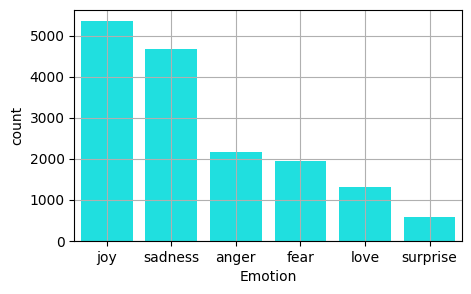

In [312]:
emotion_count_data = train_data['Emotion'].value_counts()
plt.figure(figsize=(5,3))
sns.barplot(emotion_count_data, color = 'cyan')
plt.grid(True)

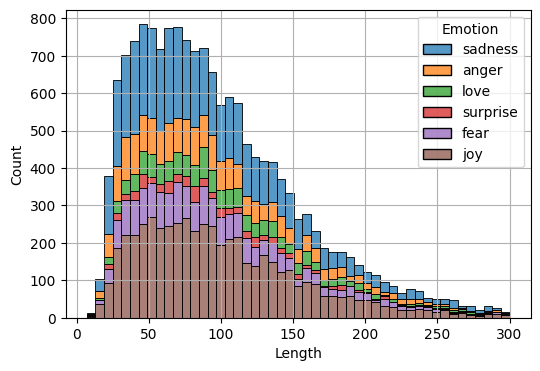

In [313]:
plt.figure(figsize=(6,4))
sns.histplot(data = train_data, x = 'Length', hue = 'Emotion', multiple = 'stack') # multiple = 'stack' ensures that the distribution is stacked one over the other. We used the hue column that is the comparing column on the basis of which we will have the color coding as Emotion based on the Length.
plt.grid(True)

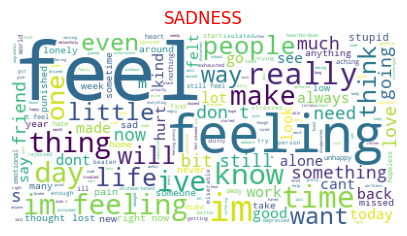

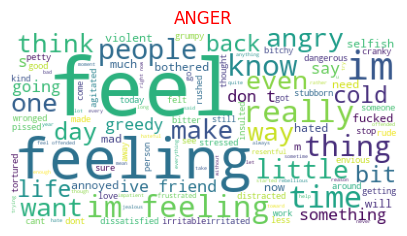

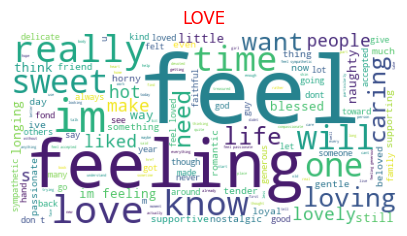

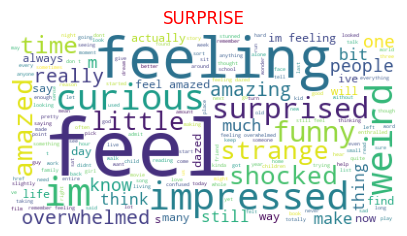

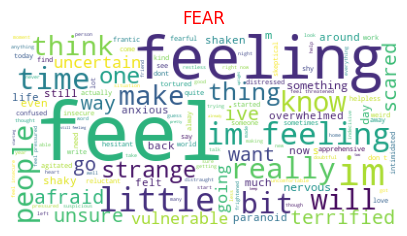

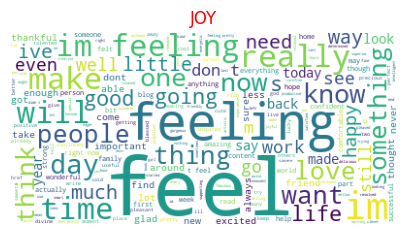

In [314]:
def word_cloud_func(wordcloud, emotion):
    cloud = WordCloud(background_color='white').generate(wordcloud)
    plt.figure(figsize=(5,5))
    plt.axis('off')
    plt.title(emotion.upper(), color = 'red')
    plt.imshow(cloud)

emotions = train_data['Emotion'].unique()
for emotion in emotions:
    subset = train_data[train_data['Emotion'] == emotion]
    word_cloud = ""
    for sentence in subset['Text']:
        word_cloud = word_cloud + (sentence + " ")
    word_cloud_func(word_cloud, emotion)

In [315]:
# Encoding the emotion
encoder = LabelEncoder()
train_data['Emotion_Encoded'] = encoder.fit_transform(train_data['Emotion'])
train_data.head()

,Text,Emotion,Length,Emotion_Encoded
0,i didnt feel humiliated,sadness,23,4
1,i can go from feeling so hopeless to so damned...,sadness,108,4
2,im grabbing a minute to post i feel greedy wrong,anger,48,0
3,i am ever feeling nostalgic about the fireplac...,love,92,3
4,i am feeling grouchy,anger,20,0


In [316]:
# Machine Learning
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

In [317]:
ml_data = train_data.copy() # Copying the dataset so that we can use it for the machine learning algorithms
ml_data = ml_data.drop(['Emotion'], axis = 1)
ml_data.head()

,Text,Length,Emotion_Encoded
0,i didnt feel humiliated,23,4
1,i can go from feeling so hopeless to so damned...,108,4
2,im grabbing a minute to post i feel greedy wrong,48,0
3,i am ever feeling nostalgic about the fireplac...,92,3
4,i am feeling grouchy,20,0


In [318]:
# Data cleaning and preprocessing for the texts
from nltk.corpus import stopwords
nltk.download('stopwords')    

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\soury\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [319]:
def clean_text(text):
    english_stopwords = set(stopwords.words('english'))
    stemmer = PorterStemmer()
    lemmatizer = WordNetLemmatizer()
    text = re.sub(r'[^a-zA-Z]', ' ', text) # Removing all non alphabets
    text = text.replace("  ", " ").lower()
    words = nltk.word_tokenize(text, language='english') # Converting the entire text into word tokens
    filtered_words = [lemmatizer.lemmatize(word) for word in words if word.lower() not in english_stopwords]
    return " ".join(filtered_words)

ml_data['Text'] = ml_data['Text'].apply(clean_text)
ml_data.head()

,Text,Length,Emotion_Encoded
0,didnt feel humiliated,23,4
1,go feeling hopeless damned hopeful around some...,108,4
2,im grabbing minute post feel greedy wrong,48,0
3,ever feeling nostalgic fireplace know still pr...,92,3
4,feeling grouchy,20,0


In [320]:
# Performing the train test split
X_train, X_test, y_train, y_test = train_test_split(ml_data['Text'], ml_data['Emotion_Encoded'], train_size=0.8, test_size=0.2, random_state = 42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((12799,), (3200,), (12799,), (3200,))

In [321]:
# Vectorization using the TfIdfVectorizer
vectorizer = TfidfVectorizer(ngram_range=(1,2))
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [322]:
# Performing up-sampling for the minority classes
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
X_train_smote.shape, y_train_smote.shape

((26004, 88382), (26004,))

In [323]:
classifiers = {
    'MultinomialNB': MultinomialNB(alpha=0.1), # alpha is the smoothing factor (laplace smoothing)
    'LogisticRegression': LogisticRegression(),
    'RandomForestClassifier': RandomForestClassifier(n_estimators=250),
    'SVC': SVC(kernel='linear'),
}
best_performer = {'name': None, 'accuracy': 0.0}
best_model = None
for name, model in classifiers.items():
    print(f'\n================== {name} ==================')
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    print('Accuracy Score:', accuracy)
    print('Classification Report:\n', report)
    if best_performer['name'] is None or best_performer['accuracy'] <= accuracy:
        best_performer = {'name': name, 'accuracy': accuracy}
        best_model = model

print(best_performer['name'], best_performer['accuracy'])


================== MultinomialNB ==================
Accuracy Score: 0.81625
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.79      0.79       439
           1       0.78      0.74      0.76       375
           2       0.84      0.87      0.85      1027
           3       0.72      0.66      0.69       303
           4       0.87      0.87      0.87       950
           5       0.59      0.62      0.61       106

    accuracy                           0.82      3200
   macro avg       0.77      0.76      0.76      3200
weighted avg       0.82      0.82      0.82      3200


================== LogisticRegression ==================
Accuracy Score: 0.900625
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90       439
           1       0.88      0.81      0.85       375
           2       0.92      0.92      0.92      1027
           3       0.81      0.8

In [324]:
# We have the best performing model in the best_model variable
model = best_model
print(best_performer['name'], best_performer['accuracy'])

LogisticRegression 0.900625


In [325]:
def predict_emotion(text):
    text = clean_text(text)
    vectorized_text = vectorizer.transform([text])
    pred_label = model.predict(vectorized_text)[0]
    conf = np.max(model.predict_proba(vectorized_text)[0])
    pred_emotion = encoder.inverse_transform([pred_label])[0] # Converts integer encoded label to their categorical name version
    return f'{pred_emotion} with confidence {conf:.2%}'

print(predict_emotion(input('Enter text: ')))

sadness with confidence 69.32%


In [326]:
# Saving the files
import pickle
with open('logistic_regression_model.pkl', 'wb') as file:
    pickle.dump(model, file)
with open('log_reg_vectorizer.pkl', 'wb') as file:
    pickle.dump(vectorizer, file)
with open('log_reg_encoder.pkl', 'wb') as file:
    pickle.dump(encoder, file)

In [348]:
# Deep Learning
from tensorflow.keras.preprocessing.text import Tokenizer
corpus = []
vocab_size = 15000
max_text = max(train_data['Length']) # 300
lemmatizer = WordNetLemmatizer()
english_stopwords = set(stopwords.words('english'))
for text in train_data['Text']:
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.lower()
    words = nltk.word_tokenize(text, language='english')
    filtered_words = [lemmatizer.lemmatize(word) for word in words if word.lower() not in english_stopwords]
    text = " ".join(filtered_words)
    corpus.append(text)

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(corpus)
sequences = tokenizer.texts_to_sequences(corpus)
X_train = pad_sequences(sequences, maxlen = max_text, padding = 'pre')

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [349]:
max_text = max(train_data['Length'])
max_text
X_train

array([[   0,    0,    0, ...,   52,    2,  566],
       [   0,    0,    0, ...,   59,  173, 1140],
       [   0,    0,    0, ...,    2,  383,  322],
       ...,
       [   0,    0,    0, ...,  227,   34, 1207],
       [   0,    0,    0, ...,  468,    5,  237],
       [   0,    0,    0, ...,    2,  179, 3302]],
      shape=(15999, 300), dtype=int32)

In [350]:
y_train = to_categorical(train_data['Emotion_Encoded'])
y_train

array([[0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0., 0.],
       ...,
       [0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0.]], shape=(15999, 6))

In [351]:
# Now let us create the model
vocab_size = 15000
embedding_dimension = 128 # size of word embeddings (according to convenience and performance)
num_classes = 6 
max_len = max_text

dl_model = Sequential()
dl_model.add(Embedding(input_dim = vocab_size, output_dim = embedding_dimension, input_length = max_len))
dl_model.add(Dropout(rate = 0.25)) # to avoid overfitting

dl_model.add(Bidirectional(LSTM(units = 48))) # We adjust the units accordingly as the performance of our model
dl_model.add(Dropout(rate = 0.3))

dl_model.add(Dense(units = 32, activation = 'relu'))
dl_model.add(Dropout(rate = 0.3))

dl_model.add(Dense(units = 6, activation = 'softmax'))

In [352]:
dl_model.compile(optimizer = 'rmsprop', loss = 'categorical_crossentropy', metrics = ['accuracy'])
early_stop = EarlyStopping(monitor = 'val_loss', patience = 3, restore_best_weights = True) # So that we can stop at the point where the model's accuracy is not getting much changed...
history = dl_model.fit(X_train, y_train, epochs = 10, batch_size = 32, validation_split = 0.1, callbacks = [early_stop])

Epoch 1/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 56s 114ms/step - accuracy: 0.3893 - loss: 1.4903 - val_accuracy: 0.7138 - val_loss: 0.9906
Epoch 2/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 64s 141ms/step - accuracy: 0.7851 - loss: 0.6945 - val_accuracy: 0.8737 - val_loss: 0.4110
Epoch 3/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 63s 140ms/step - accuracy: 0.8883 - loss: 0.3658 - val_accuracy: 0.8894 - val_loss: 0.3329
Epoch 4/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 52s 116ms/step - accuracy: 0.9201 - loss: 0.2583 - val_accuracy: 0.9038 - val_loss: 0.2716
Epoch 5/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 59s 130ms/step - accuracy: 0.9319 - loss: 0.2699 - val_accuracy: 0.9100 - val_loss: 0.2485
Epoch 6/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 55s 123ms/step - accuracy: 0.9487 - loss: 0.1643 - val_accuracy: 0.9237 - val_loss: 0.2502
Epoch 7/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 55s 121ms/step - accuracy: 0.9578 - loss: 0.1392 - val_accuracy: 0.9112 - val_loss: 0.2798
Epoch 8/10
450/450 ━━━━━━━━━━━━━━━━━━━━ 62s 138ms/step - accuracy: 0.9622 - loss: 0

In [353]:
# Checking the summary of the model
dl_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 300, 128)       │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 300, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 96)             │        67,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,982,542 (15.19 MB)

 Trainable params: 1,991,270 (7.60 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,991,272 (7.60 MB)

i am very happy and energetic today
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
Joy with confidence 99.84%


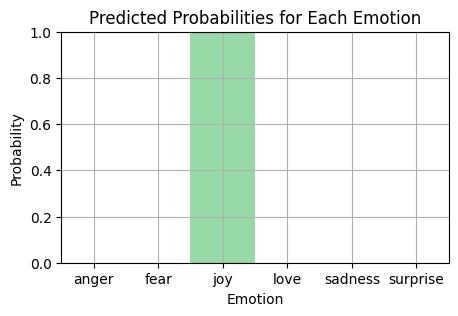

In [354]:
def predict_emotion(text):
    vocab_size = 15000
    max_text = max(train_data['Length']) # 300
    lemmatizer = WordNetLemmatizer()
    english_stopwords = set(stopwords.words('english'))
    
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.lower()
    words = nltk.word_tokenize(text, language='english')
    filtered_words = [lemmatizer.lemmatize(word) for word in words if word.lower() not in english_stopwords]
    text = " ".join(filtered_words)
    
    sequences = tokenizer.texts_to_sequences([text])
    seq = pad_sequences(sequences, maxlen = max_text, padding = 'pre')
    
    probs = dl_model.predict(seq)[0]
    pred_class = np.argmax(probs)
    pred_label = encoder.inverse_transform([pred_class])[0]
    conf = probs[pred_class]
    
    print(f'{pred_label.title()} with confidence {conf:.2%}')
    plot_data = pd.DataFrame({
        'Emotion': encoder.classes_,
        'Probability': probs
    })
    plt.figure(figsize=(5,3))
    sns.barplot(x = 'Emotion', y = 'Probability', data = plot_data, palette='pastel', width=1)
    plt.ylim(0,1)
    plt.title('Predicted Probabilities for Each Emotion')
    plt.grid(True)
    plt.show()

input_text = input('Enter text: ')
print(input_text)
predict_emotion(input_text)

In [355]:
print(dl_model.summary())

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 300, 128)       │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 300, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 96)             │        67,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,982,542 (15.19 MB)

 Trainable params: 1,991,270 (7.60 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,991,272 (7.60 MB)

None


In [356]:
# Saving the models
max_text = max(train_data['Length'])
vocab_size = 15000
dl_model.save("emotion_model_lstm.keras")

with open('dl_encoder.pkl', 'wb') as file:
    pickle.dump(encoder, file)

with open('vocab_size.pkl', 'wb') as file:
    pickle.dump(vocab_size, file)
    
with open('max_len.pkl', 'wb') as file:
    pickle.dump(max_text, file)
    
with open("tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

In [357]:
print(dl_model.summary())

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 300, 128)       │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 300, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 96)             │        67,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,982,542 (15.19 MB)

 Trainable params: 1,991,270 (7.60 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,991,272 (7.60 MB)

None


In [358]:
import sklearn
sklearn.__version__

'1.6.1'